# Variational Burgers on fake hardware

Team: Andrei Poliakov, Kyro Jeremy Gibling, Nadav Carmel, Pak Tik, Sahil Ugale

Optimizes each timestep on the ideal simulator, then reads out the same circuits on
FakeSherbrooke (qiskit-aer), shot-sampled.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from qiskit.quantum_info import Statevector

from pde_core import ansatz, get_state, get_expval_ideal, num_ansatz_params
from burgers import burgers_cost
from discretization import periodic_D2, construct_F2_periodic
from fake_hardware import make_fake_backend, noisy_decoded_state
from plot_style import set_style, COLORS
set_style()

CLASSICAL_COLOR = COLORS["classical"]
IDEAL_COLOR = COLORS["blue"]
NOISY_COLOR = COLORS["orange"]


## Setup


In [2]:
n = 3
N = 2 ** n
x = np.linspace(0, 1, N, endpoint=False)
dx = x[1] - x[0]
nu = 0.01
dt = 0.06
n_steps = 5

u0 = np.sin(2 * np.pi * x)
nparams = num_ansatz_params(n)

D2 = periodic_D2(N, dx)
F2 = -1 / (2 * dx) * construct_F2_periodic(N)
classical_states = [u0.copy()]
f = u0.copy()
for _ in range(n_steps):
    f = f + dt * (nu * (D2 @ f) + F2 @ np.kron(f, f))
    classical_states.append(f.copy())
classical_states = np.array(classical_states)


## Ideal optimization


In [3]:
amp0 = np.linalg.norm(u0)
u0n = u0 / amp0


def init_loading(theta, target):
    v = np.real(Statevector(ansatz(n, theta)).data)
    return np.sum((v - target) ** 2)


best = None
for trial in range(8):
    theta0 = np.random.default_rng(trial).random(nparams) * 2 * np.pi
    res = sp.optimize.minimize(init_loading, theta0, args=(u0n,), method="BFGS")
    if best is None or res.fun < best.fun:
        best = res
theta = np.concatenate(([amp0], best.x))

theta_trajectory = [theta.copy()]
for step in range(n_steps):
    def objective(theta_new):
        cost, _ = burgers_cost(theta_new, theta, n, dt, dx, nu, get_expval_ideal)
        return cost

    best_new = None
    for trial in range(6):
        guess = theta + np.random.default_rng(2000 + 10 * step + trial).normal(scale=0.05, size=nparams + 1)
        res = sp.optimize.minimize(objective, guess, method="COBYLA", options={"maxiter": 400})
        if best_new is None or res.fun < best_new.fun:
            best_new = res
    theta = best_new.x
    theta_trajectory.append(theta.copy())
    print(f"step {step+1}/{n_steps}: cost={best_new.fun:.5f}")


step 1/5: cost=-3.93727


step 2/5: cost=-3.98874


step 3/5: cost=-4.17342


step 4/5: cost=-4.46283


step 5/5: cost=-4.74999


## Fake-hardware readout


In [4]:
noise_model, sim, cm = make_fake_backend(n + 1)
ansatz_n = lambda t: ansatz(n, t)

ideal_states = [get_state(n, th) for th in theta_trajectory]
noisy_states = [noisy_decoded_state(ansatz_n, th, noise_model, sim, cm, n=n) for th in theta_trajectory]

rel_err = lambda a, b: np.linalg.norm(a - b) / np.linalg.norm(b)
noisy_err = [rel_err(s, ideal) for s, ideal in zip(noisy_states, ideal_states)]

for i in range(n_steps + 1):
    print(f"t={i*dt:.2f}: rel. error = {noisy_err[i]:.4f}")


t=0.00: rel. error = 0.7815
t=0.06: rel. error = 0.7997
t=0.12: rel. error = 0.7718
t=0.18: rel. error = 0.7547
t=0.24: rel. error = 0.7948
t=0.30: rel. error = 0.7940


## Results


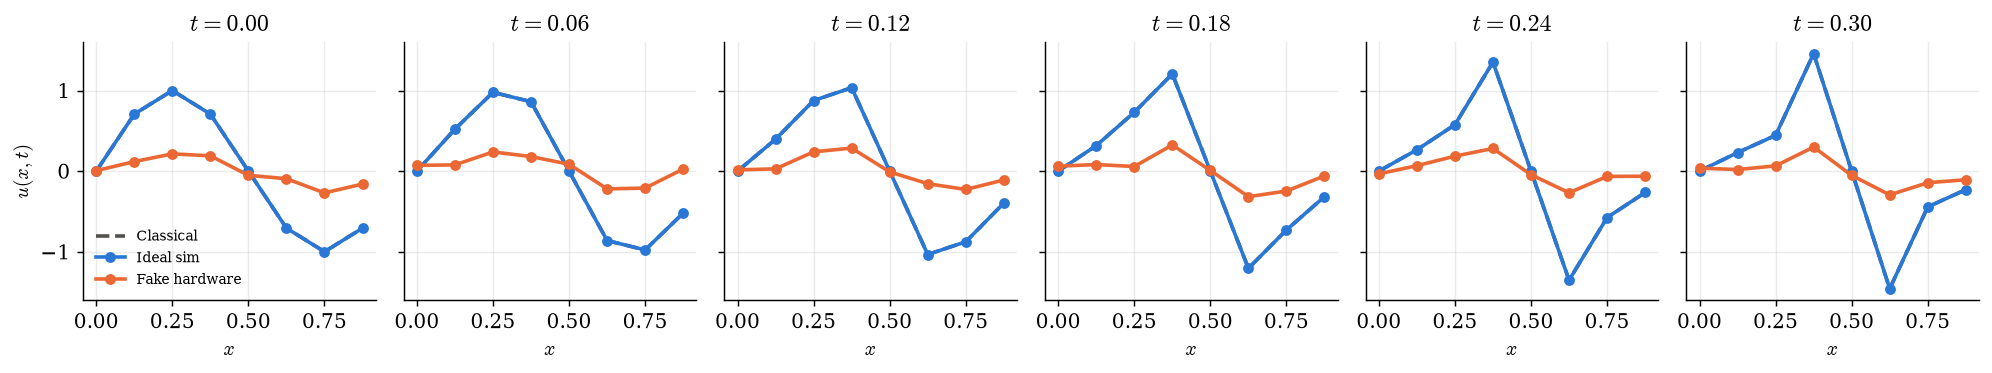

In [5]:
fig, axes = plt.subplots(1, n_steps + 1, figsize=(2.6 * (n_steps + 1), 3.0), sharey=True)
timesteps = np.arange(n_steps + 1) * dt
for i, ax in enumerate(axes):
    ax.plot(x, classical_states[i], "--", color=CLASSICAL_COLOR, label="Classical")
    ax.plot(x, ideal_states[i], "-", color=IDEAL_COLOR, marker="o", label="Ideal sim")
    ax.plot(x, noisy_states[i], "-", color=NOISY_COLOR, marker="o", label="Fake hardware")
    ax.set_title(f"$t = {timesteps[i]:.2f}$")
    ax.set_xlabel("$x$")
axes[0].set_ylabel("$u(x, t)$")
axes[0].legend(fontsize=8)
fig.tight_layout()


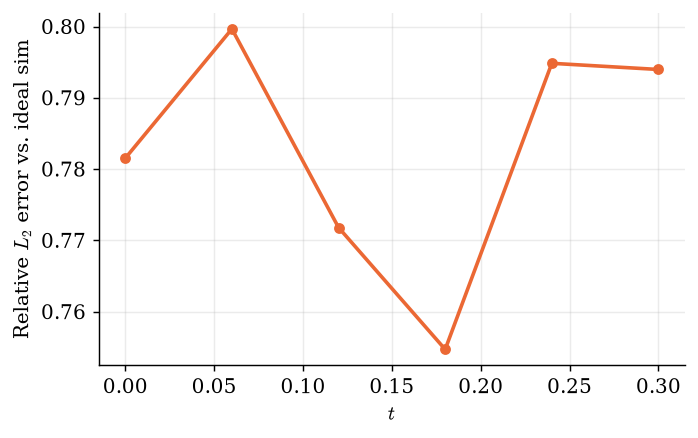

In [6]:
fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.plot(timesteps, noisy_err, "o-", color=NOISY_COLOR)
ax.set_xlabel("$t$")
ax.set_ylabel("Relative $L_2$ error vs. ideal sim")
fig.tight_layout()
